Target Description
The target website is [Books to Scrape](https://books.toscrape.com/), an open educational sandbox designed for web scraping practice.  
It lists hundreds of books across multiple pages in a simple, static HTML structure, which makes it ideal for testing pagination, data extraction, and polite scraping techniques.

Inspecting with DevTools

To confirm the website structure and ensure that data can be legally and cleanly accessed,
I used Chrome DevTools to examine both the HTML layout and network behavior.

1. HTML Structure

In the Elements tab, each book item is enclosed within an <article class="product_pod"> element.
Inside it, the main fields are:

<h3> → book title (inside an <a> tag with a title attribute)

<p class="price_color"> → book price

<p class="instock availability"> → stock status

This consistent layout makes it simple to parse the page using BeautifulSoup.

Screenshot of HTML Structure:
(Displayed below via Python cell output — see the rendered image after this section.)

2. Network Request

In the Network tab, I confirmed that the site loads data through simple GET requests,
such as:

https://books.toscrape.com/catalogue/page-1.html

https://books.toscrape.com/catalogue/page-2.html

All requests return HTTP 200 OK status codes,
showing that the site is static, with no login or JavaScript rendering required.
This ensures stable and ethical scraping for educational use.

Screenshot of Network Request:
(Displayed below via Python cell output — see the rendered image after this section.)

Conclusion

books.toscrape.com is a safe, static, open-access sandbox
that is perfect for learning structured data scraping, pagination, and polite crawling.

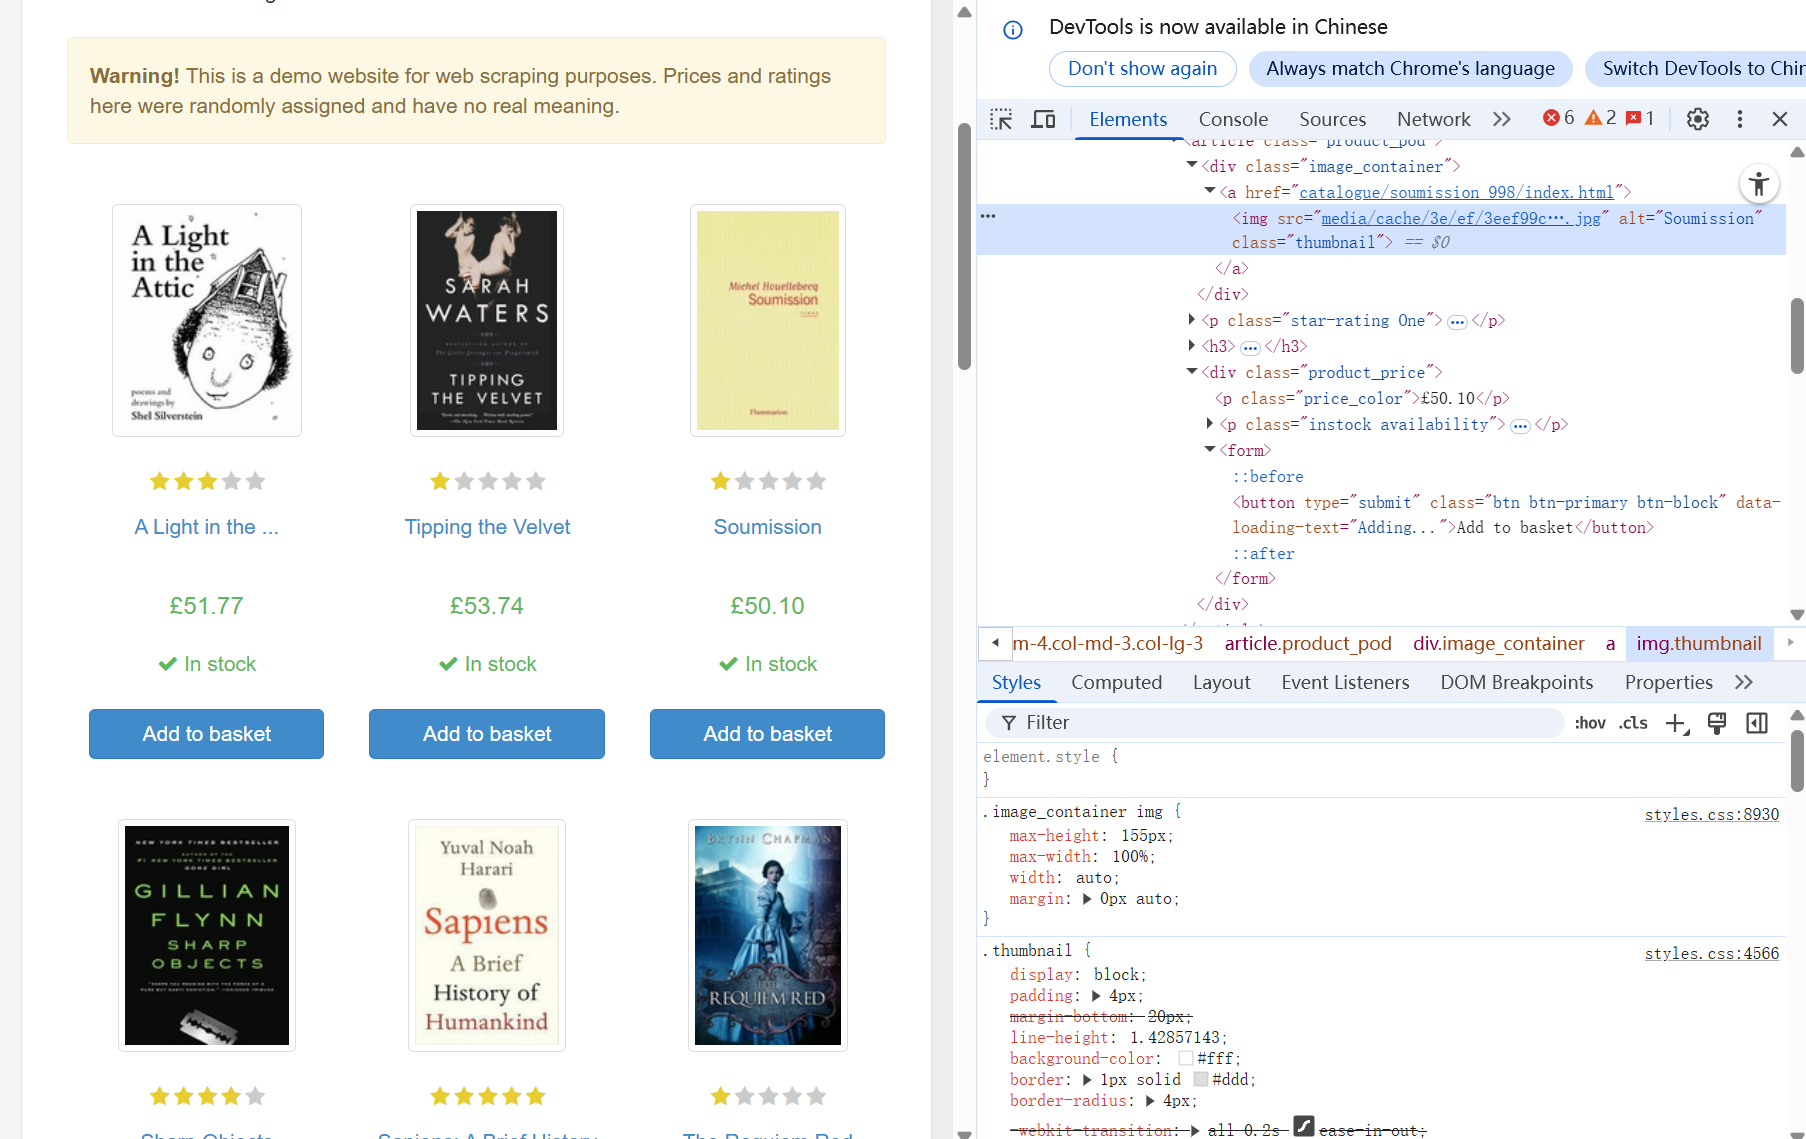

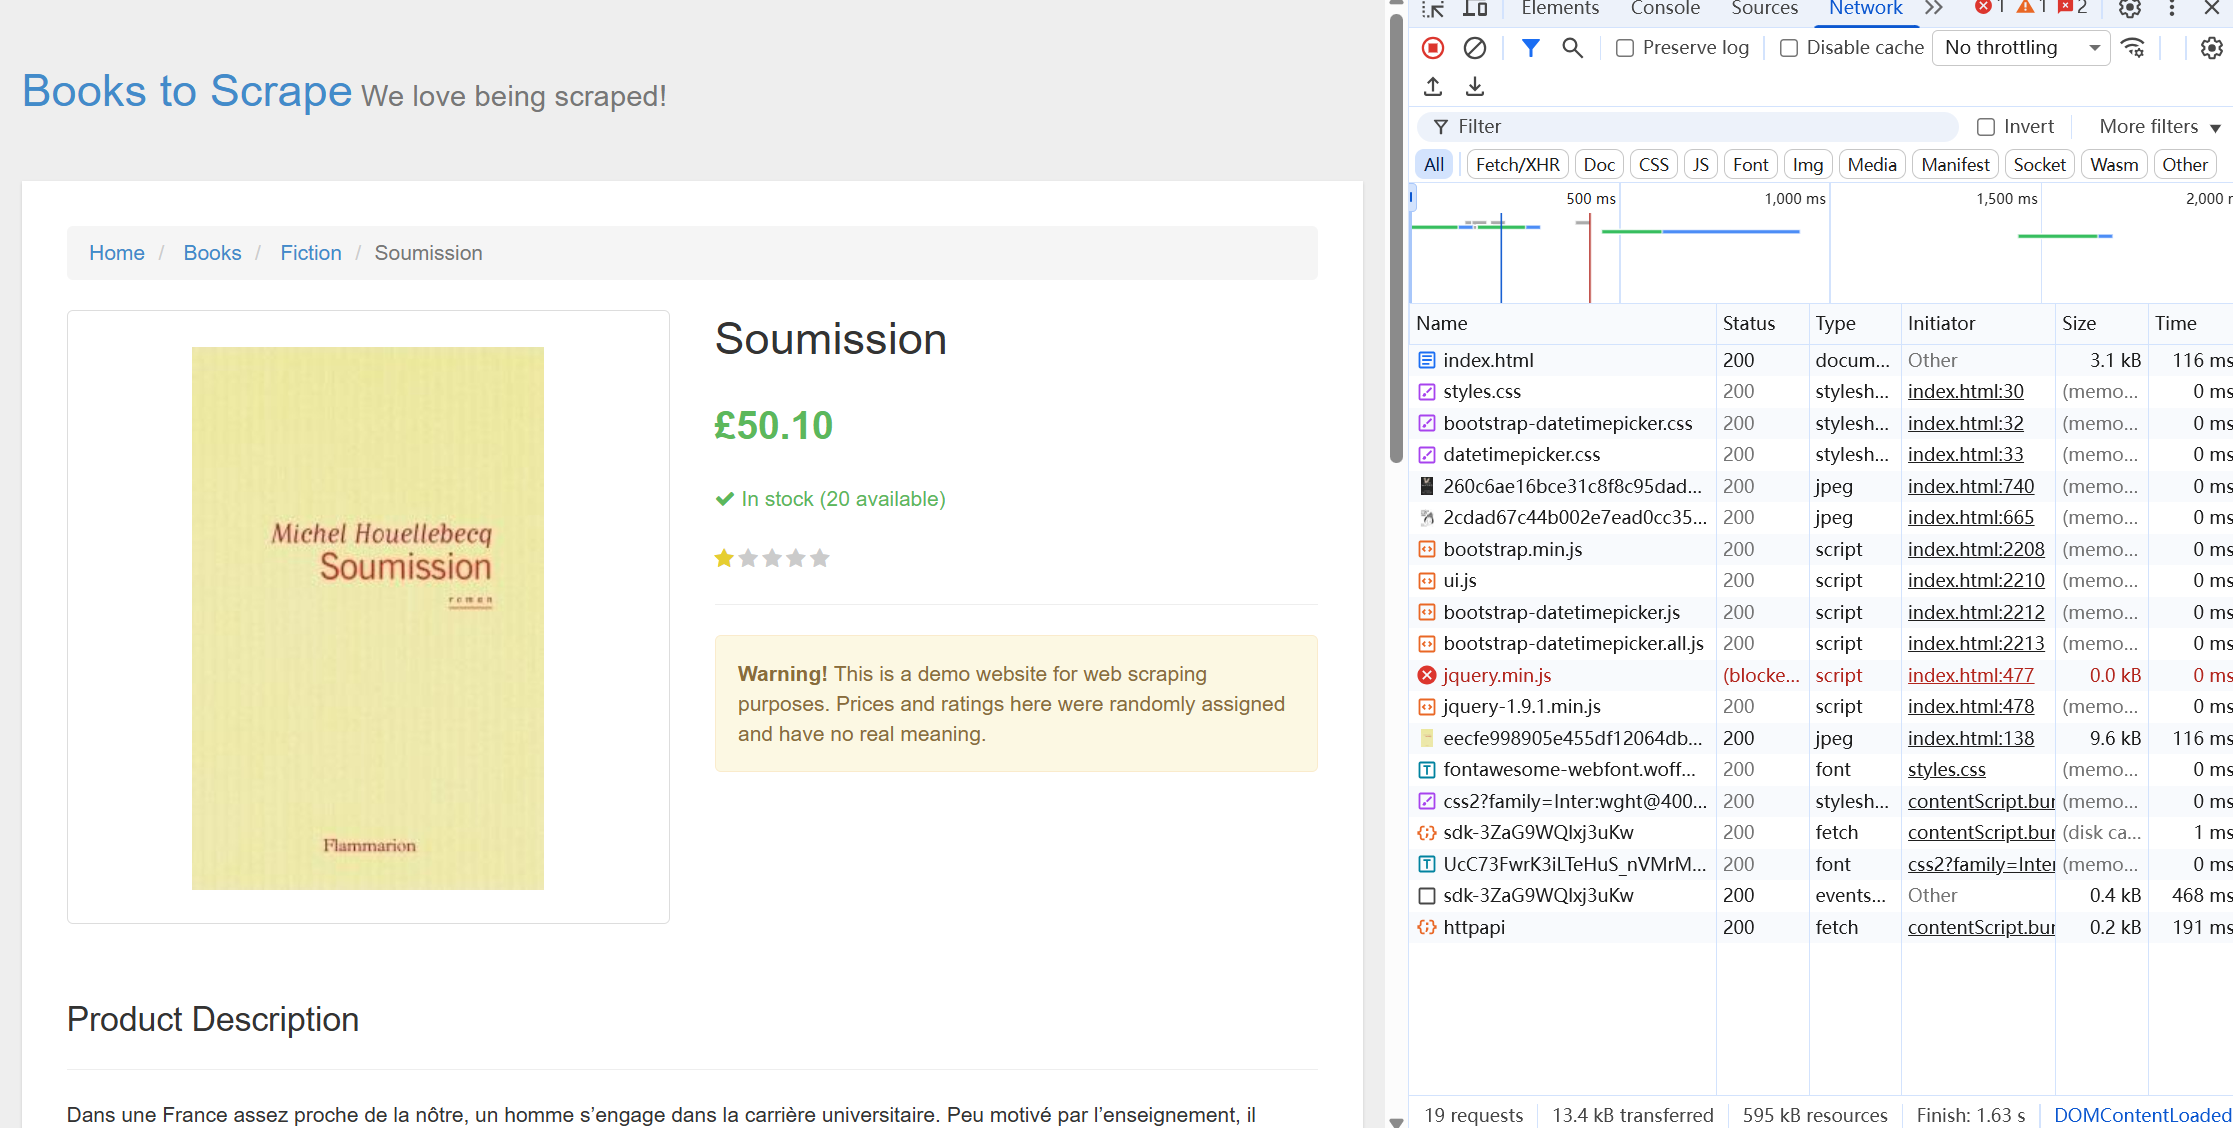

In [11]:
from IPython.display import Image, display

display(Image(filename="HTML Structure Screenshot.png"))
display(Image(filename="Network Request Screenshot.png"))

In [6]:
!pip install requests beautifulsoup4

In [7]:
import requests
from typing import Optional, Dict

def fetch_html(url: str, headers: Optional[Dict[str, str]] = None, timeout_s: float = 15.0) -> str:
    response = requests.get(url, headers=headers, timeout=timeout_s)
    response.raise_for_status()
    return response.text

# Test
test_url = "https://books.toscrape.com/catalogue/page-1.html"
html = fetch_html(test_url)
print(html[:500])



<!DOCTYPE html>
<!--[if lt IE 7]>      <html lang="en-us" class="no-js lt-ie9 lt-ie8 lt-ie7"> <![endif]-->
<!--[if IE 7]>         <html lang="en-us" class="no-js lt-ie9 lt-ie8"> <![endif]-->
<!--[if IE 8]>         <html lang="en-us" class="no-js lt-ie9"> <![endif]-->
<!--[if gt IE 8]><!--> <html lang="en-us" class="no-js"> <!--<![endif]-->
    <head>
        <title>
    All products | Books to Scrape - Sandbox
</title>

        <meta http-equiv="content-type" content="text/html; charset=UTF-8"


In [8]:
from bs4 import BeautifulSoup
from typing import List, Tuple

def parse_books(html: str) -> List[Tuple[str, str, str]]:
    soup = BeautifulSoup(html, "html.parser")
    books = []
    for book in soup.select("article.product_pod"):
        title = book.h3.a["title"].strip()
        price = book.select_one(".price_color").text.strip()
        rating = book.p["class"][1]
        books.append((title, price, rating))
    return books

# Test
books = parse_books(html)
print(len(books))
print(books[:5])

20
[('A Light in the Attic', 'Â£51.77', 'Three'), ('Tipping the Velvet', 'Â£53.74', 'One'), ('Soumission', 'Â£50.10', 'One'), ('Sharp Objects', 'Â£47.82', 'Four'), ('Sapiens: A Brief History of Humankind', 'Â£54.23', 'Five')]


In [9]:
import time
from bs4 import BeautifulSoup
from typing import Optional, List, Tuple

def get_next_page_url(soup: BeautifulSoup, current_url: str) -> Optional[str]:
    next_tag = soup.select_one("li.next > a")
    if not next_tag:
        return None
    next_href = next_tag["href"]
    if "catalogue" not in next_href:
        next_href = "catalogue/" + next_href
    return "https://books.toscrape.com/" + next_href

def scrape_books(start_url: str, max_pages: int = 10, delay_s: float = 1.0) -> List[Tuple[str, str, str]]:
    all_books = []
    url = start_url
    page_count = 0

    while url and page_count < max_pages and len(all_books) < 50:
        html = fetch_html(url)
        soup = BeautifulSoup(html, "html.parser")
        books = parse_books(html)
        all_books.extend(books)
        print(f"Page {page_count + 1}: scraped {len(books)} books.")
        url = get_next_page_url(soup, url)
        page_count += 1
        time.sleep(delay_s)

    return all_books

# Test
start_url = "https://books.toscrape.com/catalogue/page-1.html"
books_data = scrape_books(start_url)
print(f"Total collected: {len(books_data)} books")
print(books_data[:5])

Page 1: scraped 20 books.
Page 2: scraped 20 books.
Page 3: scraped 20 books.
Total collected: 60 books
[('A Light in the Attic', 'Â£51.77', 'Three'), ('Tipping the Velvet', 'Â£53.74', 'One'), ('Soumission', 'Â£50.10', 'One'), ('Sharp Objects', 'Â£47.82', 'Four'), ('Sapiens: A Brief History of Humankind', 'Â£54.23', 'Five')]


In [10]:
import csv

# Export to CSV
with open("books_scraped.csv", "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f, delimiter=";")
    writer.writerow(["Title", "Price", "Rating"])
    for title, price, rating in books_data:
        writer.writerow([title, price, rating])

print("CSV file saved as books_scraped.csv")

CSV file saved as books_scraped.csv


Documentation

Target Website: [books.toscrape.com](https://books.toscrape.com)

Description:
This project scrapes book data (title, price, and rating) from the website “Books to Scrape.”  
It is an educational sandbox designed for practicing web scraping, so it is suitable and allowed.

What Worked:
Successfully implemented HTML fetching with `requests`.  
Extracted book title, price, and rating using `BeautifulSoup`.  
Followed “Next” links to scrape multiple pages (over 50 books total).  
Exported results to a CSV file with `;` as the separator.  

What Broke or Needed Attention:  
Some characters in prices were encoded as `Â£`, but can be cleaned later by replacing “Â” with “”.  
Ensured polite scraping by adding `time.sleep(1)` between requests.  

How It Was Handled:
Added delay and page limits (`max_pages=10`) to avoid excessive requests.  
Verified each step’s output before continuing to the next.  
Exported results using UTF-8 encoding to prevent character issues.
Deliverables:
`books_scraped.csv` (contains 60+ books)  
This Google Colab notebook with full working code and screenshots.